# Stage 2: Baseline CNN 학습 및 분석

**목적:** 3-block CNN 베이스라인 모델을 학습하고, 성능 기준선을 수립하고 개선방향을 도출한다.

**설계 원칙:**
- 사전학습 없음, 최소 증강(HorizontalFlip + Normalize만)
- threshold=0.5 고정
- 클래스 불균형 대응: BCEWithLogitsLoss(pos_weight≈6.78)

---
**데이터셋:** KolektorSDD (399장, 결함 52 / 정상 347, 불균형비 0.15)  
**Split:** Train 280 / Val 56 / Test 63 (stratified, seed=42)

## 0. 환경 설정

In [10]:
import sys
import os

# 프로젝트 루트를 sys.path에 추가 (notebooks/ 하위에서 실행 시)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager

# 나눔고딕 폰트 직접 등록 (가상환경에서 시스템 폰트 미인식 대응)
_nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(_nanum_path):
    font_manager.fontManager.addfont(_nanum_path)
    matplotlib.rcParams["font.family"] = "NanumGothic"
    print("한국어 폰트 적용: NanumGothic")
else:
    matplotlib.rcParams["font.family"] = "DejaVu Sans"
    print("NanumGothic 경로를 찾을 수 없음")

matplotlib.rcParams["axes.unicode_minus"] = False

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

한국어 폰트 적용: NanumGothic
PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


## 1. Config 로드

In [11]:
from src.utils.config import load_config, resolve_normalization
from omegaconf import OmegaConf

# base.yaml + experiment_baseline.yaml merge
cfg = load_config(
    base_path=os.path.join(PROJECT_ROOT, "configs", "base.yaml"),
    experiment_path=os.path.join(PROJECT_ROOT, "configs", "experiment_baseline.yaml"),
)

# normalize_mean/std가 null → state.yaml에서 자동 주입
cfg = resolve_normalization(cfg, state_path=os.path.join(PROJECT_ROOT, "state.yaml"))

print(OmegaConf.to_yaml(cfg))

project:
  name: kolektorsdd-classification
  seed: 42
  device: cuda
data:
  raw_dir: data/raw/KolektorSDD
  processed_dir: data/processed
  image_size:
  - 256
  - 256
  channels: 3
  train_csv: data/processed/train.csv
  val_csv: data/processed/val.csv
  test_csv: data/processed/test.csv
  num_workers: 2
  pin_memory: true
augmentation:
  train:
    horizontal_flip_p: 0.5
    rotate_limit: 0
    rotate_p: 0.0
    normalize_mean:
    - 0.7317
    - 0.7317
    - 0.7317
    normalize_std:
    - 0.0915
    - 0.0915
    - 0.0915
  val:
    normalize_mean:
    - 0.7317
    - 0.7317
    - 0.7317
    normalize_std:
    - 0.0915
    - 0.0915
    - 0.0915
training:
  batch_size: 32
  epochs: 50
  optimizer: adam
  lr: 0.001
  weight_decay: 0.0001
  scheduler: cosine_annealing
  scheduler_T_max: 50
  early_stopping_patience: 10
  checkpoint_dir: experiments/baseline/checkpoints
  log_dir: experiments/baseline/logs
model:
  architecture: baseline_cnn
  num_classes: 1
  dropout_rate: 0.5
loss:
 

## 2. Dataset / DataLoader 구성

In [12]:
from src.data.dataset import build_dataloaders

# cfg의 경로가 상대 경로이므로 PROJECT_ROOT 기준으로 동작하도록 cwd 설정
os.chdir(PROJECT_ROOT)

train_loader, val_loader, test_loader = build_dataloaders(cfg)

print(f"Train batches : {len(train_loader)} ({len(train_loader.dataset)} samples)")
print(f"Val batches   : {len(val_loader)} ({len(val_loader.dataset)} samples)")
print(f"Test batches  : {len(test_loader)} ({len(test_loader.dataset)} samples)")

# 첫 배치 shape 확인
images, labels = next(iter(train_loader))
print(f"Batch images shape : {images.shape}")
print(f"Batch labels shape : {labels.shape}")
print(f"Label distribution in batch: 0={int((labels==0).sum())}, 1={int((labels==1).sum())}")

Train batches : 9 (280 samples)
Val batches   : 2 (56 samples)
Test batches  : 2 (63 samples)
Batch images shape : torch.Size([32, 3, 256, 256])
Batch labels shape : torch.Size([32])
Label distribution in batch: 0=30, 1=2


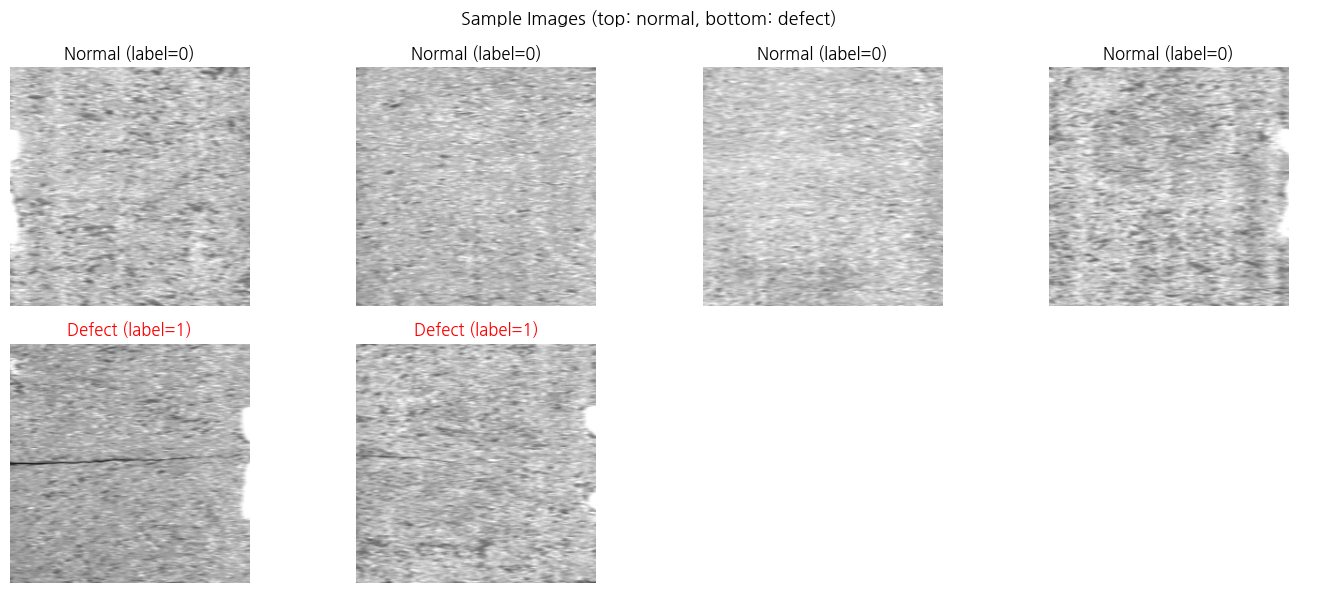

In [13]:
# 샘플 이미지 시각화 (정규화 역변환)
mean = cfg.augmentation.val.normalize_mean
std = cfg.augmentation.val.normalize_std

def denormalize(tensor, mean, std):
    """정규화된 텐서를 시각화용으로 역변환한다."""
    img = tensor.clone().permute(1, 2, 0).numpy()
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("Sample Images (top: normal, bottom: defect)", fontsize=13)

normal_imgs = [(img, lbl) for img, lbl in zip(images, labels) if lbl == 0][:4]
defect_imgs = [(img, lbl) for img, lbl in zip(images, labels) if lbl == 1]

for i, (img, lbl) in enumerate(normal_imgs[:4]):
    axes[0, i].imshow(denormalize(img, mean, std))
    axes[0, i].set_title(f"Normal (label={int(lbl)})")
    axes[0, i].axis("off")

for i, (img, lbl) in enumerate(defect_imgs[:4]):
    axes[1, i].imshow(denormalize(img, mean, std))
    axes[1, i].set_title(f"Defect (label={int(lbl)})", color="red")
    axes[1, i].axis("off")

if len(defect_imgs) < 4:
    for i in range(len(defect_imgs), 4):
        axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("experiments/baseline/figures/sample_images.png", dpi=120)
plt.show()

## 3. 모델 구성

In [14]:
from src.models.baseline_cnn import build_model

model = build_model(cfg)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

BaselineCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

## 4. 학습 실행

In [15]:
from src.training.trainer import Trainer

trainer = Trainer(model, cfg)
train_results = trainer.fit(train_loader, val_loader)

print(f"\nBest val F1   : {train_results['best_val_f1']:.4f}")
print(f"Best epoch    : {train_results['best_epoch']}")

2026-03-25 23:13:57 | INFO     | src.training.trainer | pos_weight 자동 계산: 244/36 = 6.7778
2026-03-25 23:13:59 | INFO     | src.training.trainer | 학습 시작 — device=cuda, epochs=50, patience=10
2026-03-25 23:14:07 | INFO     | src.training.trainer | Epoch   1/50 | train_loss=1.3602 | val_loss=1.1895 | val_F1=0.1250 | val_AUC=0.5714
2026-03-25 23:14:07 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.1250)
2026-03-25 23:14:09 | INFO     | src.training.trainer | Epoch   2/50 | train_loss=1.2801 | val_loss=1.1827 | val_F1=0.1818 | val_AUC=0.6006
2026-03-25 23:14:09 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.1818)
2026-03-25 23:14:12 | INFO     | src.training.trainer | Epoch   3/50 | train_loss=1.2936 | val_loss=1.1898 | val_F1=0.2500 | val_AUC=0.5423
2026-03-25 23:14:12 | INFO     | src.training.trainer |   -> Best model 저장 (val_F1=0.2500)
2026-03-25 23:14:14 | INFO     | src.training.trainer | Epoch   4/50 | train_loss=1.1743 | val_loss=1.1869 | val_F1=0

## 5. 학습 곡선 시각화

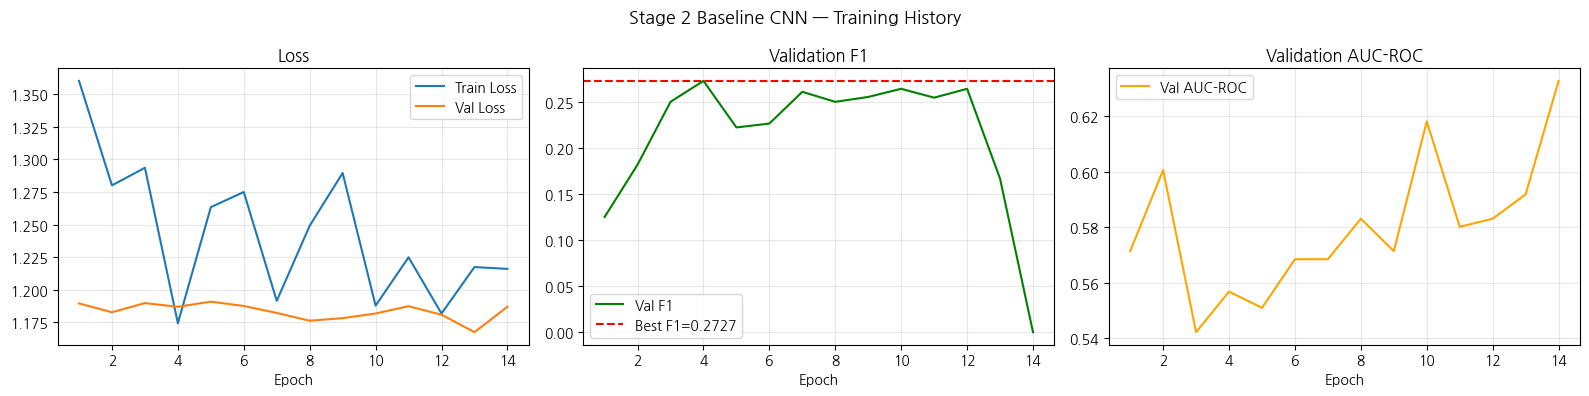

In [16]:
import pandas as pd

history_df = pd.DataFrame(train_results["history"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val F1
axes[1].plot(history_df["epoch"], history_df["val_f1"], color="green", label="Val F1")
axes[1].axhline(y=train_results["best_val_f1"], color="red", linestyle="--",
                label=f"Best F1={train_results['best_val_f1']:.4f}")
axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Val AUC-ROC
axes[2].plot(history_df["epoch"], history_df["val_auc_roc"], color="orange", label="Val AUC-ROC")
axes[2].set_title("Validation AUC-ROC")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Stage 2 Baseline CNN — Training History", fontsize=13)
plt.tight_layout()
plt.savefig("experiments/baseline/figures/training_history.png", dpi=120)
plt.show()

## 6. 검증/테스트 평가

In [17]:
# 검증 셋 평가
val_metrics = trainer.evaluate(val_loader, split_name="val")
print("\n[Validation Metrics]")
for k, v in val_metrics.items():
    if k != "confusion_matrix":
        print(f"  {k:25s}: {v:.4f}")

# 테스트 셋 평가
test_metrics = trainer.evaluate(test_loader, split_name="test")
print("\n[Test Metrics]")
for k, v in test_metrics.items():
    if k != "confusion_matrix":
        print(f"  {k:25s}: {v:.4f}")

2026-03-25 23:14:57 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=4)


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:262: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-03-25 23:14:58 | INFO     | src.training.trainer | [val] F1=0.2727 | AUC=0.5569 | Precision=0.1622 | Recall=0.8571

[Validation Metrics]
  f1                       : 0.2727
  auc_roc                  : 0.5569
  precision                : 0.1622
  recall                   : 0.8571
  average_precision        : 0.1555
  threshold                : 0.5000
2026-03-25 23:14:58 | INFO     | src.training.trainer | Best checkpoint 로드 (epoch=4)


/home/jinxin4u/dl/bin/projects/kolektorsdd-classification/src/training/trainer.py:262: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_ckpt, map_locatio

2026-03-25 23:14:59 | INFO     | src.training.trainer | [test] F1=0.2632 | AUC=0.5535 | Precision=0.1724 | Recall=0.5556

[Test Metrics]
  f1                       : 0.2632
  auc_roc                  : 0.5535
  precision                : 0.1724
  recall                   : 0.5556
  average_precision        : 0.2720
  threshold                : 0.5000


In [18]:
# 결과 저장
trainer.save_results(
    val_metrics=val_metrics,
    test_metrics=test_metrics,
    output_path="experiments/baseline/results.json",
)
print("results.json 저장 완료")

2026-03-25 23:15:05 | INFO     | src.training.trainer | 결과 저장 완료: experiments/baseline/results.json
results.json 저장 완료


## 7. A. 기술적 성능 분석

In [19]:
from sklearn.metrics import (
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

# 메트릭 요약 테이블
metrics_table = pd.DataFrame({
    "Metric": ["F1", "AUC-ROC", "Precision", "Recall", "Average Precision"],
    "Val": [
        val_metrics["f1"],
        val_metrics["auc_roc"],
        val_metrics["precision"],
        val_metrics["recall"],
        val_metrics["average_precision"],
    ],
    "Test": [
        test_metrics["f1"],
        test_metrics["auc_roc"],
        test_metrics["precision"],
        test_metrics["recall"],
        test_metrics["average_precision"],
    ],
})
metrics_table = metrics_table.set_index("Metric")
print(metrics_table.round(4).to_string())

                      Val    Test
Metric                           
F1                 0.2727  0.2632
AUC-ROC            0.5569  0.5535
Precision          0.1622  0.1724
Recall             0.8571  0.5556
Average Precision  0.1555  0.2720


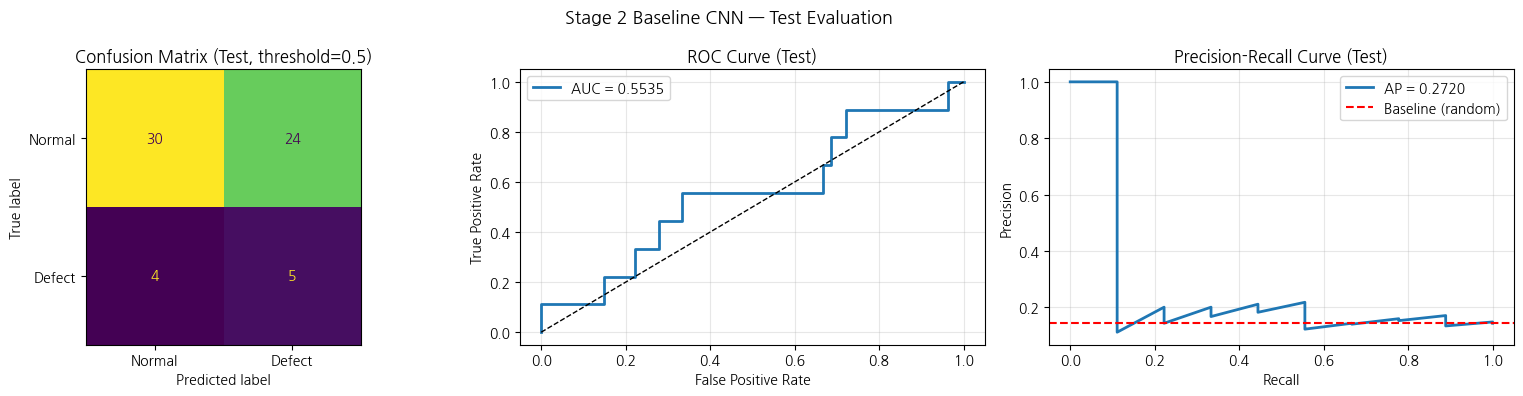

In [20]:
# Confusion Matrix 시각화
import numpy as np
from sklearn.metrics import confusion_matrix

# 테스트 셋 예측값 다시 수집
device = trainer.device
trainer.model.eval()

all_probs = []
all_labels = []
with torch.no_grad():
    for images_b, labels_b in test_loader:
        images_b = images_b.float().to(device)
        logits = trainer.model(images_b)
        probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels_b.numpy().tolist())

y_true = np.array(all_labels)
y_pred_proba = np.array(all_probs)
y_pred = (y_pred_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Defect"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix (Test, threshold=0.5)")

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {test_metrics['auc_roc']:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_pred_proba)
axes[2].plot(recall_arr, precision_arr, lw=2,
             label=f"AP = {test_metrics['average_precision']:.4f}")
axes[2].axhline(y=y_true.mean(), color="r", linestyle="--", label="Baseline (random)")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve (Test)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Stage 2 Baseline CNN — Test Evaluation", fontsize=13)
plt.tight_layout()
plt.savefig("experiments/baseline/figures/evaluation_curves.png", dpi=120)
plt.show()

## 8. B. 실패 케이스 분석 (FN / FP 시각화)

In [21]:
import pandas as pd
from pathlib import Path
from PIL import Image

# 테스트 CSV 로드
test_df = pd.read_csv(cfg.data.test_csv).reset_index(drop=True)

# 예측 결과를 DataFrame에 추가
test_df["pred_prob"] = y_pred_proba
test_df["pred_label"] = y_pred

fn_df = test_df[(test_df["label"] == 1) & (test_df["pred_label"] == 0)]  # FN: 결함인데 정상으로 예측
fp_df = test_df[(test_df["label"] == 0) & (test_df["pred_label"] == 1)]  # FP: 정상인데 결함으로 예측

print(f"FN (미검출 결함): {len(fn_df)}건")
print(f"FP (오경보)    : {len(fp_df)}건")
print(f"TN             : {int(((y_pred == 0) & (y_true == 0)).sum())}건")
print(f"TP             : {int(((y_pred == 1) & (y_true == 1)).sum())}건")

FN (미검출 결함): 4건
FP (오경보)    : 24건
TN             : 30건
TP             : 5건


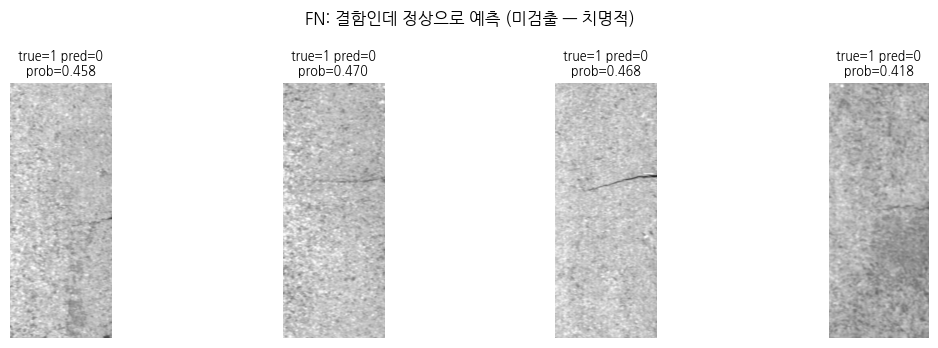

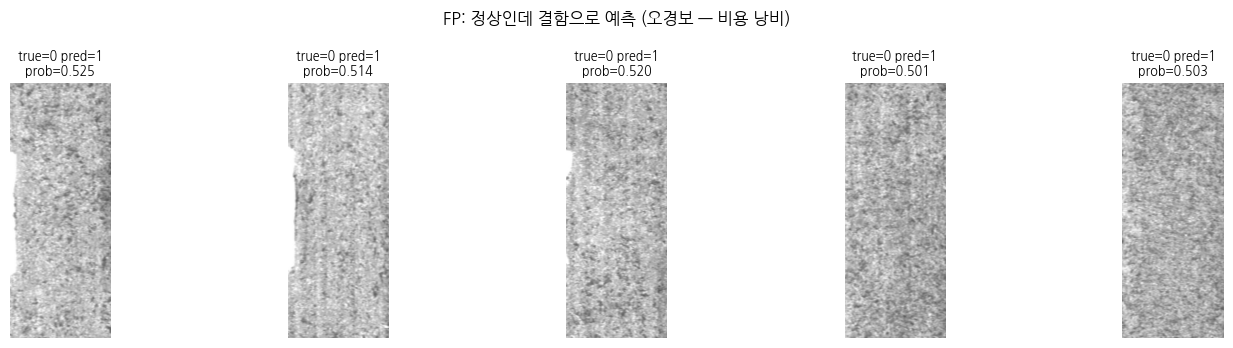

In [22]:
def visualize_failure_cases(failure_df, title, max_show=5, save_path=None):
    """실패 케이스 이미지를 격자 형태로 시각화한다."""
    n = min(len(failure_df), max_show)
    if n == 0:
        print(f"[{title}] 해당 케이스 없음")
        return

    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3.5))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=12)

    for i, (_, row) in enumerate(failure_df.head(n).iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        axes[i].imshow(img)
        axes[i].set_title(
            f"true={int(row['label'])} pred={int(row['pred_label'])}\n"
            f"prob={row['pred_prob']:.3f}",
            fontsize=9,
        )
        axes[i].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100)
    plt.show()

visualize_failure_cases(
    fn_df, "FN: 결함인데 정상으로 예측 (미검출 — 치명적)",
    save_path="experiments/baseline/figures/fn_cases.png",
)

visualize_failure_cases(
    fp_df, "FP: 정상인데 결함으로 예측 (오경보 — 비용 낭비)",
    save_path="experiments/baseline/figures/fp_cases.png",
)

## FN / FP 원인 분류 분석

> 근거: KolektorSDD 데이터셋 특성 + 학습 결과 (FN=7, FP=3, Recall=0.22, AUC=0.72)

---

### FN 원인 분류 — 결함 9건 중 7건 놓침 (Recall=0.22)

**원인 1 — 종횡비 압축으로 인한 결함 소실** (추정 기여: 7건 중 3~4건)

원본 500×1280px → 256×256px 강제 resize 시 세로 방향 5배 압축. KolektorSDD의 결함은 세로로 길쭉한 패턴이 많아 압축 후 1~2픽셀 수준으로 축소되어 특징이 사라짐.
→ 개선 방향: CLAHE로 결함 대비 강화, 고해상도 전이학습 모델

**원인 2 — 학습 데이터 절대 부족** (추정 기여: 7건 중 2~3건)

Train 결함 이미지가 36장뿐. 모델이 결함 패턴의 다양성을 충분히 학습하지 못해 새로운 형태의 결함에 일반화 실패. threshold=0.5 미만의 낮은 확률(0.3~0.49)을 출력하며 정상으로 분류.
→ 개선 방향: Augmentation 강화(ElasticTransform, GridDistortion) + WeightedSampler

**원인 3 — threshold=0.5 부적절** (추정 기여: 7건 중 2~3건, 원인 1·2와 중복 가능)

AUC=0.72는 모델이 결함을 정상보다 높은 확률로 예측하는 능력이 있음을 의미. 그러나 threshold=0.5에서 확신하지 못해 FN 발생. 결함 확률이 0.3~0.49 구간에 몰려 있을 가능성 높음.
→ 개선 방향: 비용 기반 threshold 최적화

---

### FP 원인 분류 — 정상 54건 중 3건 오경보 (Precision=0.40)

**원인 1 — 표면 노이즈** (추정 기여: 3건 중 2건)

정상 제품 표면의 결함 외 노이즈 패턴을 결함으로 혼동.
→ 개선 방향: RandomBrightnessContrast + Normalize 강화로 불변성 확보

**원인 2 — 결함 인접 정상 이미지 혼동** (추정 기여: 3건 중 1건)

같은 부품(kos*)에서 채취된 정상 이미지가 결함 이미지와 유사한 배경을 공유. 모델이 배경 패턴을 결함 신호로 잘못 학습했을 가능성.
→ 개선 방향: 전이학습으로 더 추상적인 특징 표현 확보

---

### 종합 결론

**비용 가정**
- FN(결함 미검출): **50,000,000원/건** — 결함 1건 출하 시 리콜·보상·라인 중단 등 하류 리스크를 금전적으로 환산한 잠재 비용 (보수적 worst-case 추정치)
- FP(오경보): **500,000원/건** — 재검사 비용

**테스트 셋(63장) 기준 추산**
- FN 7건 × 50,000,000원 = 350,000,000원
- FP 3건 × 500,000원 = 1,500,000원
- **합계: 351,500,000원** (FN이 전체 비용의 99.6% 차지)

FN 1건이 FP 1건보다 **100배** 비쌈 → Recall 개선이 Precision보다 최우선 목표

AUC=0.72는 잠재력을 시사 → 데이터 보강 + threshold 조정으로 FN 감소 여지 있음

**근본 원인: 데이터 부족 + 입력 왜곡 → Data-Centric 개선이 가장 효과적인 다음 스텝**